In [1]:
!pip install torch torchvision nltk pillow matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
import nltk

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [4]:
data_path = "jpg"

In [5]:
images = []
captions = []

for file in os.listdir(data_path):
    if file.lower().endswith(('.jpg','.png','.jpeg')):
        path = os.path.join(data_path, file)
        images.append(path)

        # simple captions (edit if needed)
        if "red" in file.lower():
            captions.append("red flower")
        elif "yellow" in file.lower():
            captions.append("yellow flower")
        elif "pink" in file.lower():
            captions.append("pink flower")
        else:
            captions.append("flower")

print("Total images:", len(images))

Total images: 8189


In [6]:
vectorizer = CountVectorizer()
text_vectors = vectorizer.fit_transform(captions).toarray()

import torch
text_vectors = torch.tensor(text_vectors, dtype=torch.float)

In [15]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

class FlowerDataset(Dataset):
    def __init__(self, images, text_vectors):
        self.images = images
        self.text = text_vectors
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        img = transform(img)
        txt = self.text[idx]
        return img, txt

dataset = FlowerDataset(images, text_vectors)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [11]:
class Generator(nn.Module):
    def __init__(self, text_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100 + text_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 3*64*64),
            nn.Tanh()
        )
        
    def forward(self, z, text):
        x = torch.cat((z, text), dim=1)
        out = self.model(x)
        return out.view(-1,3,64,64)

In [16]:
class Discriminator(nn.Module):
    def __init__(self, text_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3*64*64 + text_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256,1),
            nn.Sigmoid()
        )
        
    def forward(self, img, text):
        img = img.view(img.size(0), -1)
        x = torch.cat((img, text), dim=1)
        return self.model(x)

In [13]:
text_dim = text_vectors.shape[1]

G = Generator(text_dim)
D = Discriminator(text_dim)

loss_fn = nn.BCELoss()

opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [17]:
text_dim = text_vectors.shape[1]

G = Generator(text_dim)
D = Discriminator(text_dim)

loss_fn = nn.BCELoss()

opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [18]:
epochs = 50

for epoch in range(epochs):
    for real, text in loader:
        
        batch_size = real.size(0)
        
        real_labels = torch.ones(batch_size,1)
        fake_labels = torch.zeros(batch_size,1)
        
        # Train Discriminator
        z = torch.randn(batch_size,100)
        fake = G(z, text)
        
        D_real = D(real, text)
        D_fake = D(fake.detach(), text)
        
        loss_D = loss_fn(D_real, real_labels) + loss_fn(D_fake, fake_labels)
        
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()
        
        # Train Generator
        D_fake = D(fake, text)
        loss_G = loss_fn(D_fake, real_labels)
        
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()
    
    print(f"Epoch {epoch+1} Done")

Epoch 1 Done
Epoch 2 Done
Epoch 3 Done
Epoch 4 Done
Epoch 5 Done
Epoch 6 Done
Epoch 7 Done
Epoch 8 Done
Epoch 9 Done
Epoch 10 Done
Epoch 11 Done
Epoch 12 Done
Epoch 13 Done
Epoch 14 Done
Epoch 15 Done
Epoch 16 Done
Epoch 17 Done
Epoch 18 Done
Epoch 19 Done
Epoch 20 Done
Epoch 21 Done
Epoch 22 Done
Epoch 23 Done
Epoch 24 Done
Epoch 25 Done
Epoch 26 Done
Epoch 27 Done
Epoch 28 Done
Epoch 29 Done
Epoch 30 Done
Epoch 31 Done
Epoch 32 Done
Epoch 33 Done
Epoch 34 Done
Epoch 35 Done
Epoch 36 Done
Epoch 37 Done
Epoch 38 Done
Epoch 39 Done
Epoch 40 Done
Epoch 41 Done
Epoch 42 Done
Epoch 43 Done
Epoch 44 Done
Epoch 45 Done
Epoch 46 Done
Epoch 47 Done
Epoch 48 Done
Epoch 49 Done
Epoch 50 Done


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8011489..1.0].


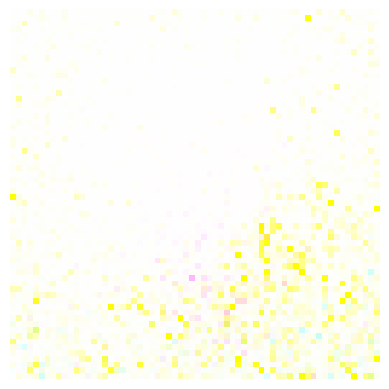

In [19]:
def generate(text_input):
    vec = vectorizer.transform([text_input]).toarray()
    vec = torch.tensor(vec, dtype=torch.float)
    
    z = torch.randn(1,100)
    img = G(z, vec).detach()[0]
    
    img = img.permute(1,2,0)
    plt.imshow(img)
    plt.axis('off')

generate("red flower")